In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder


Loading the dataset into a pandas DataFrame

In [4]:
df = pd.read_csv('data/boxoffice.csv',encoding='latin-1')
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bondâs past sends him...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


 Checking Dataset 

In [5]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

Exploring DATASET


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
budget,4803.0,2.904504e+07,4.072239e+07,0.0,790000.00000,1.500000e+07,4.000000e+07,3.800000e+08
id,4803.0,5.716548e+04,8.869461e+04,5.0,9014.50000,1.462900e+04,5.861050e+04,4.594880e+05
popularity,4803.0,2.149230e+01,3.181665e+01,0.0,4.66807,1.292159e+01,2.831350e+01,8.755813e+02
revenue,4803.0,8.226064e+07,1.628571e+08,0.0,0.00000,1.917000e+07,9.291719e+07,2.787965e+09
runtime,4801.0,1.068759e+02,2.261193e+01,0.0,94.00000,1.030000e+02,1.180000e+02,3.380000e+02
vote_average,4803.0,6.092172e+00,1.194612e+00,0.0,5.60000,6.200000e+00,6.800000e+00,1.000000e+01
vote_count,4803.0,6.902180e+02,1.234586e+03,0.0,54.00000,2.350000e+02,7.370000e+02,1.375200e+04


Since we are predicting only domestic revenue in this project, we are dropping world_revenue and opening_revenue columns from the dataframe.

In [27]:

df.drop(columns=['world_revenue','opening_revenue'],inplace=True)
df.head()

,title,domestic_revenue,distributor,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,Warner Bros.,253,174687337,R,Animation,16
1,Titanic,169411543,Disney,122,103948486,G,Action,103
2,Jurassic Park,107836098,Sony,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,Disney,3868,46431596,G,Horror,85
4,The Lion King,142791649,Warner Bros.,2934,203513696,R,Comedy,158


Visualizing

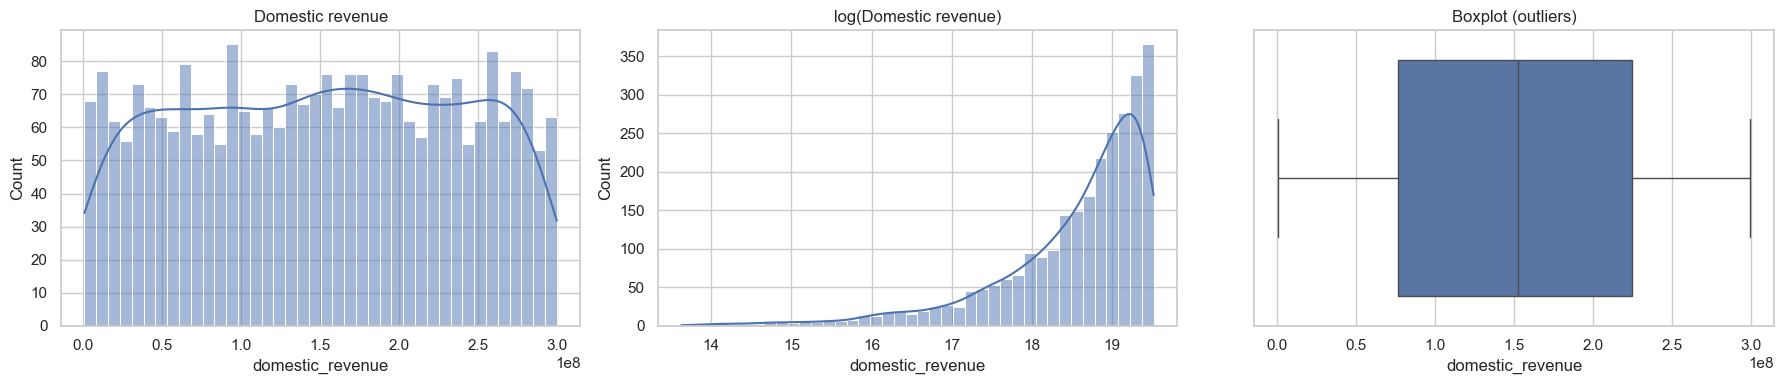

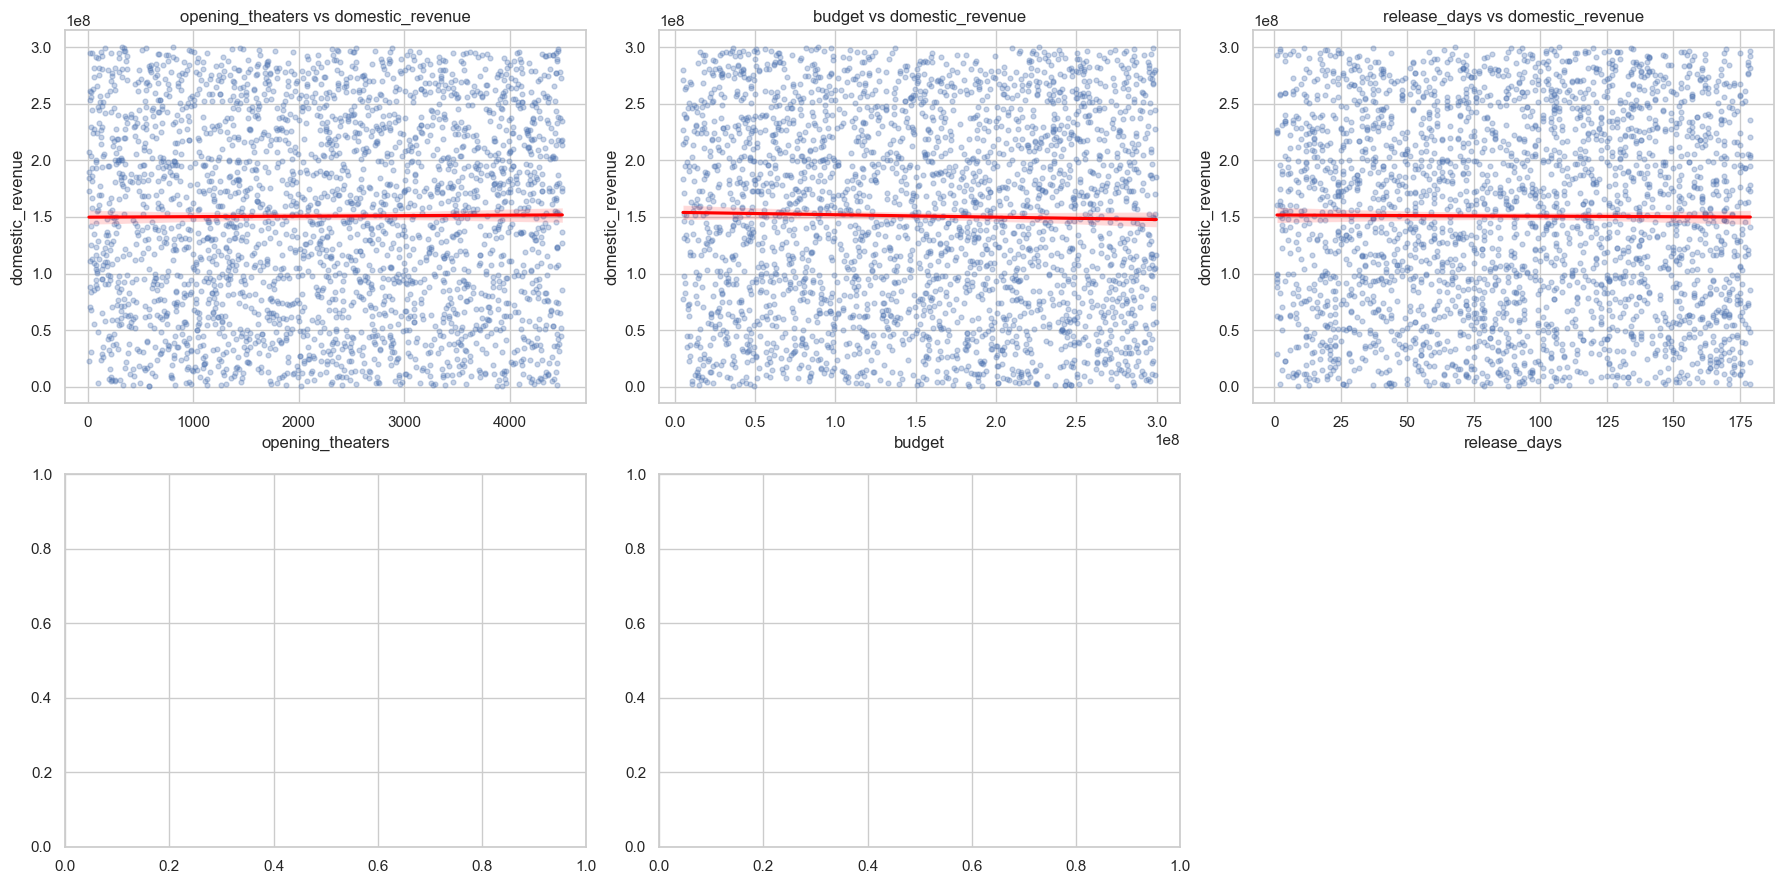

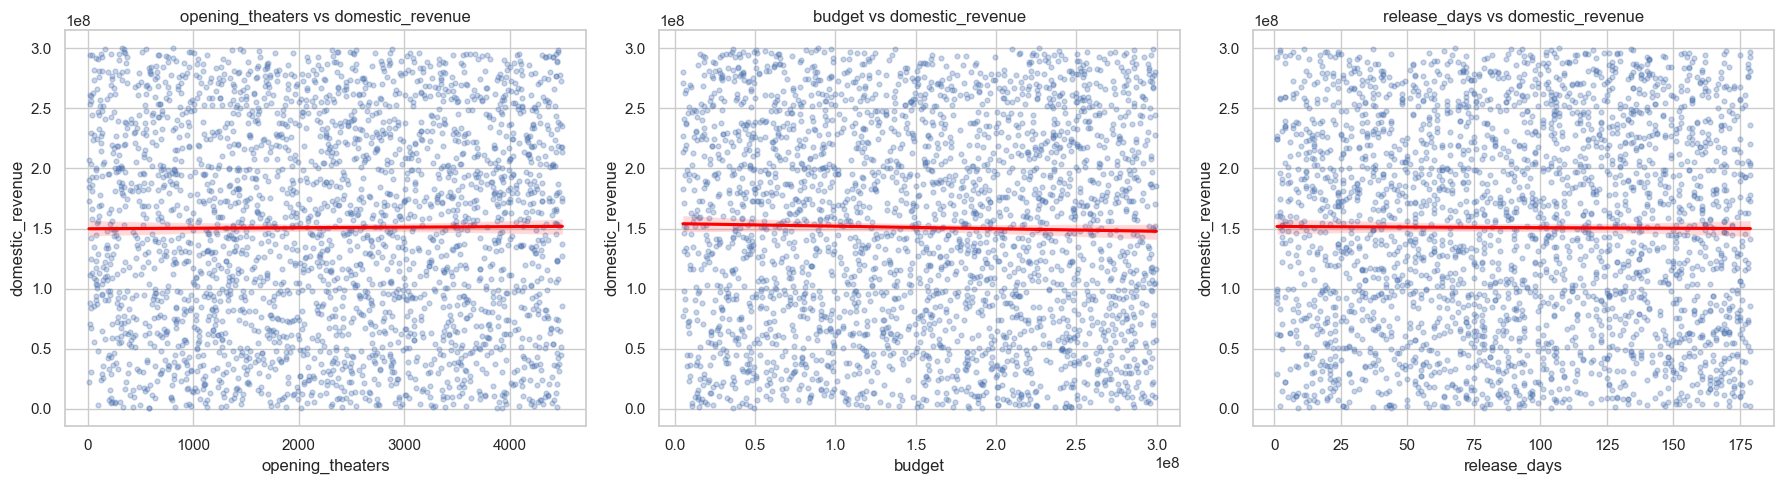

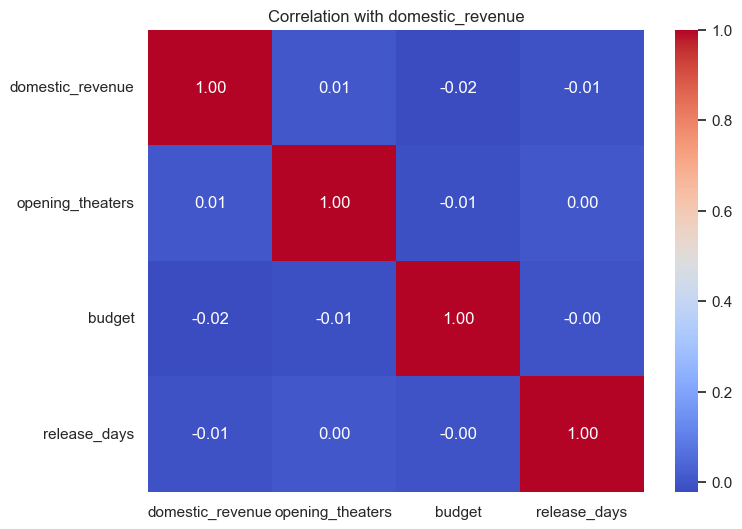

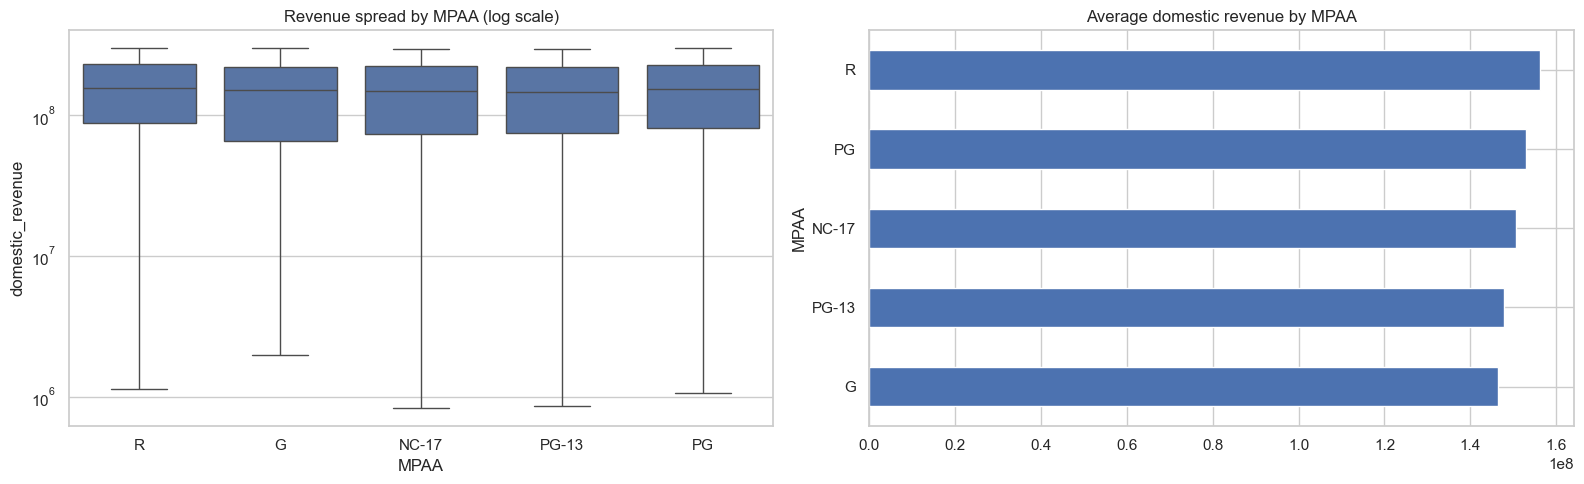

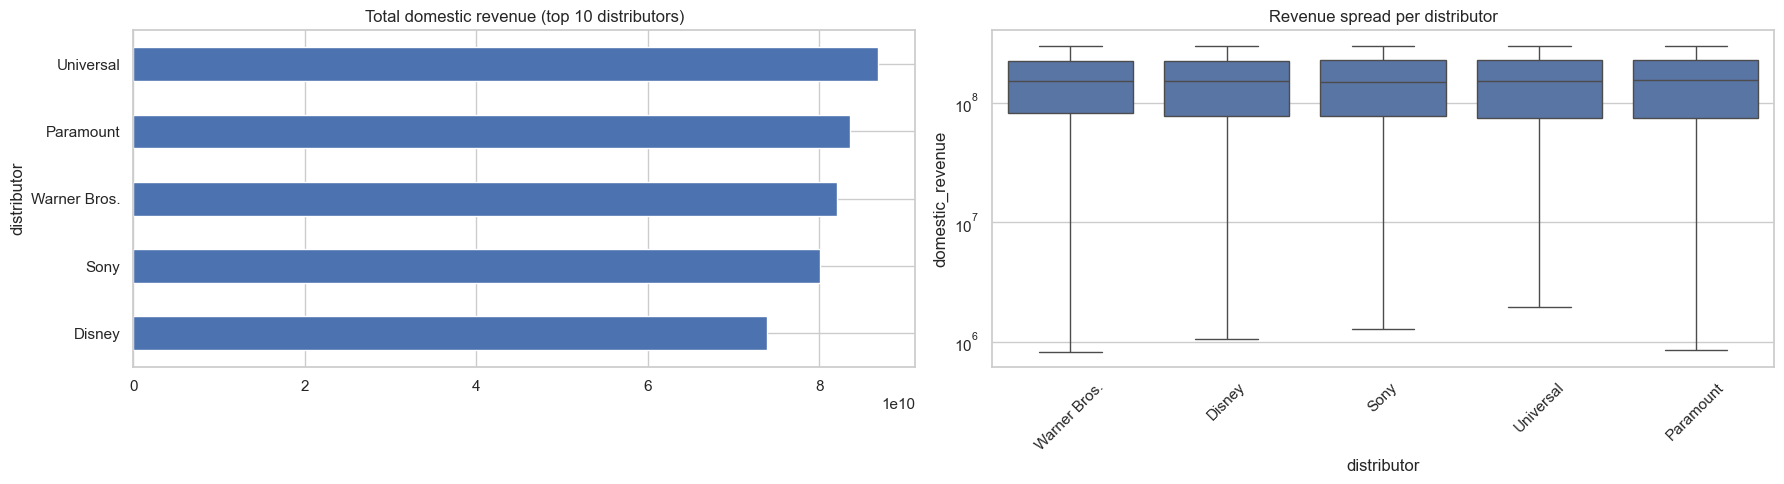

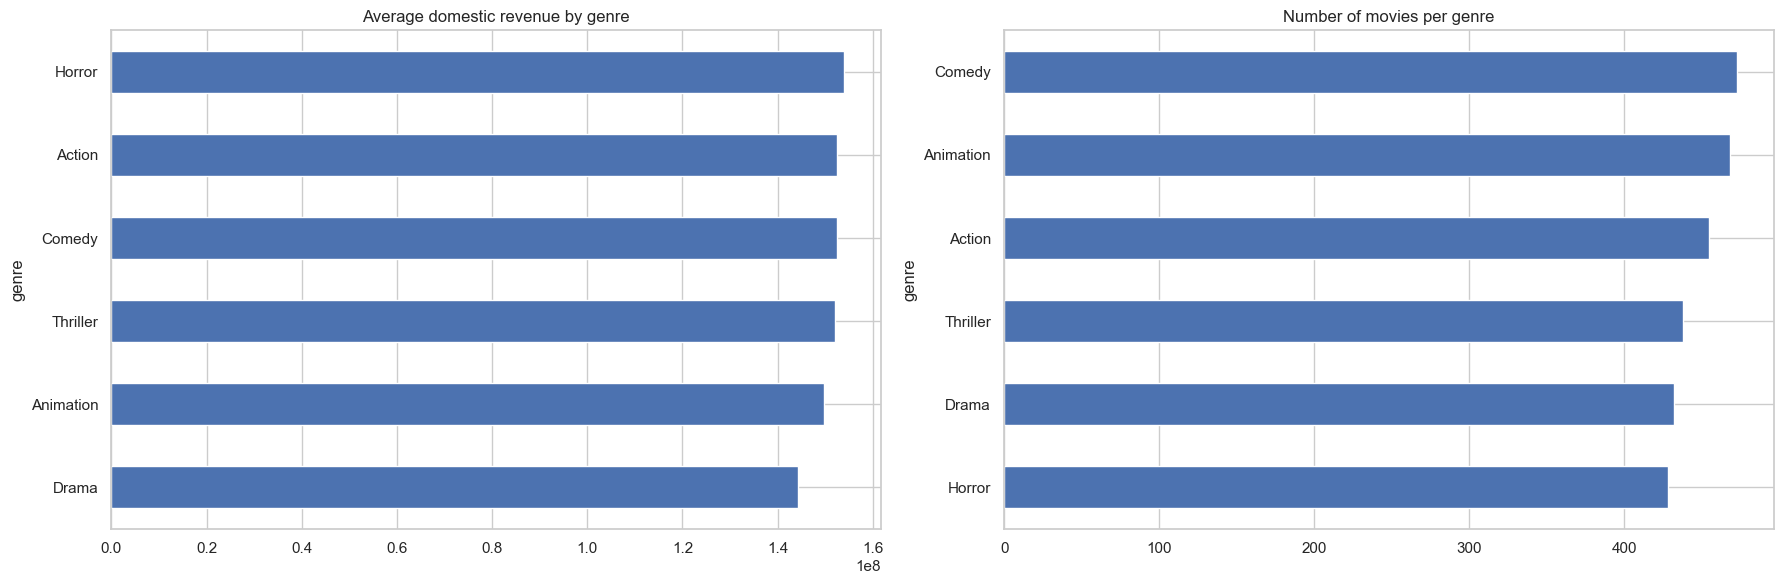

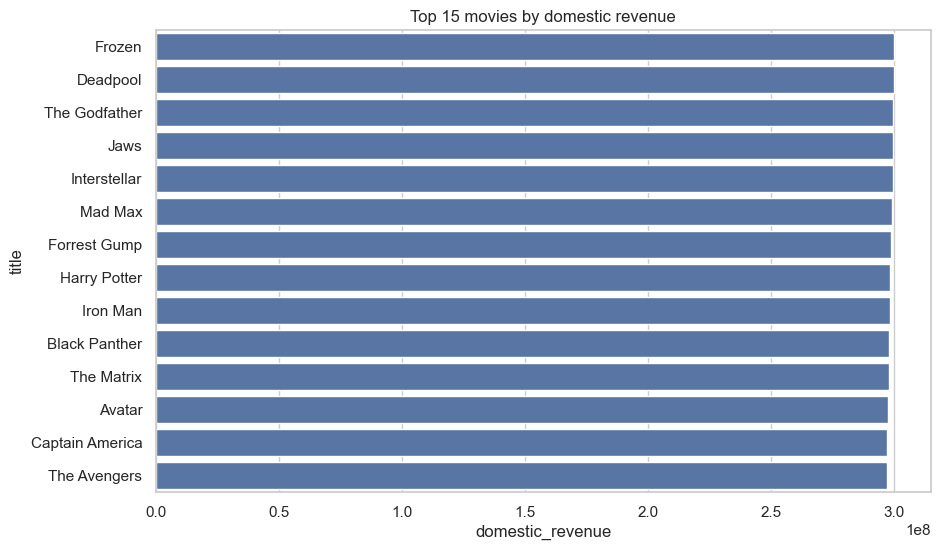

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
target = "domestic_revenue"

# 1. Distribution of domestic_revenue itself (raw vs log)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df[target], bins=40, kde=True, ax=ax[0])
ax[0].set_title("Domestic revenue")
sns.histplot(np.log1p(df[target]), bins=40, kde=True, ax=ax[1])
ax[1].set_title("log(Domestic revenue)")
sns.boxplot(x=df[target], ax=ax[2])
ax[2].set_title("Boxplot (outliers)")
plt.tight_layout(); plt.show()

# 2. Numeric columns vs domestic_revenue (scatter + trend line)
num_cols = ["opening_theaters", "budget", "release_days"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, c in zip(axes.flat, num_cols):
    sns.regplot(x=df[c], y=df[target], ax=ax,
                scatter_kws={"alpha": 0.3, "s": 12}, line_kws={"color": "red"})
    ax.set_title(f"{c} vs {target}")
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

# 3. Same numeric plots on log scale (revenue data is heavily skewed)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, c in zip(axes.flat, num_cols):
    sns.regplot(x=df[c], y=df[target], ax=ax,
                scatter_kws={"alpha": 0.3, "s": 12}, line_kws={"color": "red"})
    ax.set_title(f"{c} vs {target}")
plt.tight_layout()
plt.show()


# 4. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[[target] + num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with domestic_revenue")
plt.show()

# 5. MPAA rating vs domestic_revenue
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(x="MPAA", y=target, data=df, ax=ax[0])
ax[0].set_yscale("log"); ax[0].set_title("Revenue spread by MPAA (log scale)")
df.groupby("MPAA")[target].mean().sort_values().plot(kind="barh", ax=ax[1])
ax[1].set_title("Average domestic revenue by MPAA")
plt.tight_layout(); plt.show()

# 6. Distributor vs domestic_revenue (top 10 by total revenue)
top_dist = df.groupby("distributor")[target].sum().nlargest(10).index
d = df[df["distributor"].isin(top_dist)]
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
d.groupby("distributor")[target].sum().sort_values().plot(kind="barh", ax=ax[0])
ax[0].set_title("Total domestic revenue (top 10 distributors)")
sns.boxplot(x="distributor", y=target, data=d, ax=ax[1])
ax[1].set_yscale("log"); ax[1].tick_params(axis="x", rotation=45)
ax[1].set_title("Revenue spread per distributor")
plt.tight_layout(); plt.show()

# 7. Genres vs domestic_revenue (split the pipe-separated genres)
g = df.assign(genre=df["genres"].str.split("|")).explode("genre")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
g.groupby("genre")[target].mean().sort_values().plot(kind="barh", ax=ax[0])
ax[0].set_title("Average domestic revenue by genre")
g["genre"].value_counts().sort_values().plot(kind="barh", ax=ax[1])
ax[1].set_title("Number of movies per genre")
plt.tight_layout(); plt.show()

# 8. Title: it's an identifier, so show the top 15 earners instead
top = df.nlargest(15, target)
plt.figure(figsize=(10, 6))
sns.barplot(x=target, y="title", data=top, orient="h")
plt.title("Top 15 movies by domestic revenue")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_25684\2322430376.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[col])
C:\Users\DELL\AppData\Local\Temp\ipykernel_25684\2322430376.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[col])
C:\Users\DELL\AppData\Local\Temp\ipykernel_25684\2322430

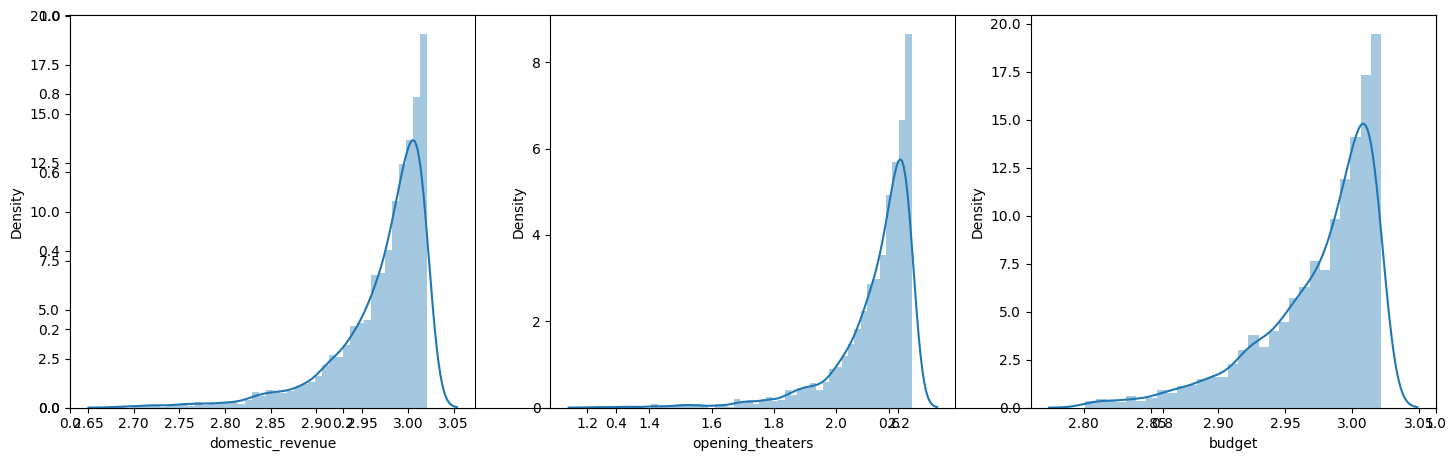

In [10]:
features = ['domestic_revenue','opening_theaters', 'budget']

for col in features:
    df[col] = np.log1p(df[col])

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sb.distplot(df[col])
plt.tight_layout()
plt.show()

 Converting Movie Genres into Numeric Features

there will be certain genres that are not that frequent which will lead to increases in the complexity of the model unnecessarily. So we will remove those genres which are very rare.

In [11]:
removed = 0

if 'action' in df.columns and 'western' in df.columns:
    for col in df.loc[:, 'action':'western'].columns: 
        
        if (df[col] == 0).mean() > 0.95: 
            removed += 1
            df.drop(col, axis=1, inplace=True) 

print(removed) 
print(df.shape)

0
(2694, 10)
